In [2]:
# install libraries

%pip install pandas
%pip install scikit-learn
%pip install numpy
%pip install torch

In [3]:
# =====================================================
# HOSPITAL OPERATIONS ANALYTICS
# =====================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


DATA_PATH = "/content/drive/MyDrive/synthetic_mimic"
print("Loading master dataset...")

master = pd.read_csv(
    f"{DATA_PATH}/master_dataset.csv"
)

print("Dataset loaded successfully.")

print()
print("Dataset Shape")
print(master.shape)

print()
print("Dataset Preview")
print(master.head())

print(master.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading master dataset...
Dataset loaded successfully.

Dataset Shape
(25059, 35)

Dataset Preview
   hadm_id  subject_id   admittime   dischtime  los_days admission_type  \
0   200000      100000  2022-01-06  2022-01-23        17         URGENT   
1   200001      100000  2019-11-08  2019-11-20        12       ELECTIVE   
2   200002      100000  2023-09-04  2023-09-23        19       ELECTIVE   
3   200003      100000  2023-06-14  2023-06-28        14         URGENT   
4   200004      100001  2019-08-15  2019-08-23         8    OBSERVATION   

  discharge_location  anchor_age gender      race  ...  CHF  CKD  COPD  \
0            EXPIRED          69      M     ASIAN  ...    0    0     1   
1               HOME          69      M     ASIAN  ...    0    0     1   
2              REHAB          69      M     ASIAN  ...    0    0     1   
3            EXPIRED     

In [4]:
# research question
print(
    """
How efficiently is the hospital operating,
and where are bottlenecks occurring?

This notebook examines hospital performance
using length of stay, ICU utilization,
resource consumption, readmissions,
and mortality rates.
"""
)


How efficiently is the hospital operating,
and where are bottlenecks occurring?

This notebook examines hospital performance
using length of stay, ICU utilization,
resource consumption, readmissions,
and mortality rates.



In [5]:
# hospital KPI dashboard
# =====================================================

# average length of stay
average_los = master["los_days"].mean()

print()
print("Average Length of Stay: " + str(round(average_los, 2)) + " days")

# median length of stay
median_los = master["los_days"].median()

print()
print("Median Length of Stay: " + str(round(median_los, 2)) + " days")

# average ICU stay
average_icu_los = master["icu_los"].mean()

print()
print("Average ICU Length of Stay: " + str(round(average_icu_los, 2)) + " days")

# readmission rate
readmission_rate = master["readmit_30d"].mean()
print()
print("Readmission Rate: " + str(round(readmission_rate * 100, 2)) + "%")

# mortality rate
mortality_rate = master["mortality"].mean()

print()
print("Mortality Rate: " + str(round(mortality_rate * 100, 2)) + "%")

# average resource score
average_resource_score = master["resource_score"].mean()

print()
print("Average Resource Score: " + str(round(average_resource_score, 2)))


# KPI scorecard
kpi_table = pd.DataFrame()

kpi_table["Metric"] = [
    "Average LOS",
    "Median LOS",
    "Average ICU LOS",
    "Readmission Rate",
    "Mortality Rate",
    "Average Resource Score"
]

kpi_table["Value"] = [
    average_los,
    median_los,
    average_icu_los,
    readmission_rate,
    mortality_rate,
    average_resource_score
]

print(kpi_table)


Average Length of Stay: 10.0 days

Median Length of Stay: 10.0 days

Average ICU Length of Stay: 3.99 days

Readmission Rate: 14.86%

Mortality Rate: 9.96%

Average Resource Score: 20.37
                   Metric      Value
0             Average LOS  10.002793
1              Median LOS  10.000000
2         Average ICU LOS   3.991712
3        Readmission Rate   0.148609
4          Mortality Rate   0.099645
5  Average Resource Score  20.365338


In [6]:
# admission type analysi
# =====================================================

# total admissions
admission_counts = master.groupby(
    "admission_type"
)["hadm_id"].count()

# average LOS
average_los_by_type = master.groupby(
    "admission_type"
)["los_days"].mean()

# average resource score
average_resource_by_type = master.groupby(
    "admission_type"
)["resource_score"].mean()

# average ICU LOS
average_icu_by_type = master.groupby(
    "admission_type"
)["icu_los"].mean()

# readmission rate
readmission_by_type = master.groupby(
    "admission_type"
)["readmit_30d"].mean()

# mortality rate
mortality_by_type = master.groupby(
    "admission_type"
)["mortality"].mean()

# combine everything into one table

admission_analysis = pd.DataFrame()

admission_analysis["Admissions"] = admission_counts

admission_analysis["Average_LOS"] = average_los_by_type

admission_analysis["Average_Resource"] = average_resource_by_type

admission_analysis["Average_ICU_LOS"] = average_icu_by_type

admission_analysis["Readmission_Rate"] = readmission_by_type

admission_analysis["Mortality_Rate"] = mortality_by_type

admission_analysis = admission_analysis.reset_index()

print(admission_analysis)

  admission_type  Admissions  Average_LOS  Average_Resource  Average_ICU_LOS  \
0       ELECTIVE        6332     9.993051         20.275111         3.985458   
1      EMERGENCY        6281     9.891896         20.427002         3.985814   
2    OBSERVATION        6236    10.067832         20.428801         4.009267   
3         URGENT        6210    10.059581         20.331240         3.986424   

   Readmission_Rate  Mortality_Rate  
0          0.144188        0.097126  
1          0.151727        0.099666  
2          0.144965        0.101988  
3          0.153623        0.099839  


In [7]:
# bottlenecks
# =====================================================

#los botteneck
los_rank = admission_analysis.sort_values(
    by="Average_LOS",
    ascending=False
)

print(los_rank)


# resource bottlenecks
resource_rank = admission_analysis.sort_values(
    by="Average_Resource",
    ascending=False
)

print(resource_rank)


# readmission bottlenecks
readmission_rank = admission_analysis.sort_values(
    by="Readmission_Rate",
    ascending=False
)

print(readmission_rank)


# ICU bottlenecks
icu_rank = admission_analysis.sort_values(
    by="Average_ICU_LOS",
    ascending=False
)

print(icu_rank)

  admission_type  Admissions  Average_LOS  Average_Resource  Average_ICU_LOS  \
2    OBSERVATION        6236    10.067832         20.428801         4.009267   
3         URGENT        6210    10.059581         20.331240         3.986424   
0       ELECTIVE        6332     9.993051         20.275111         3.985458   
1      EMERGENCY        6281     9.891896         20.427002         3.985814   

   Readmission_Rate  Mortality_Rate  
2          0.144965        0.101988  
3          0.153623        0.099839  
0          0.144188        0.097126  
1          0.151727        0.099666  
  admission_type  Admissions  Average_LOS  Average_Resource  Average_ICU_LOS  \
2    OBSERVATION        6236    10.067832         20.428801         4.009267   
1      EMERGENCY        6281     9.891896         20.427002         3.985814   
3         URGENT        6210    10.059581         20.331240         3.986424   
0       ELECTIVE        6332     9.993051         20.275111         3.985458   

   Readm

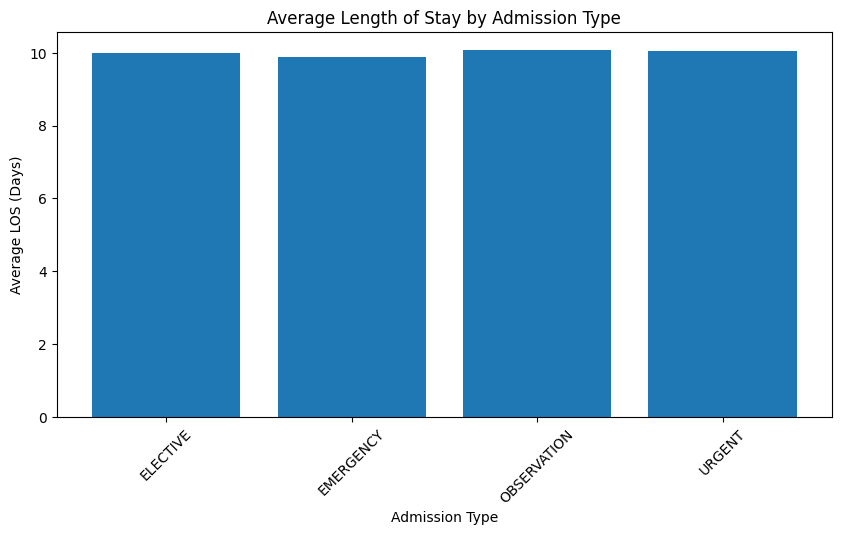

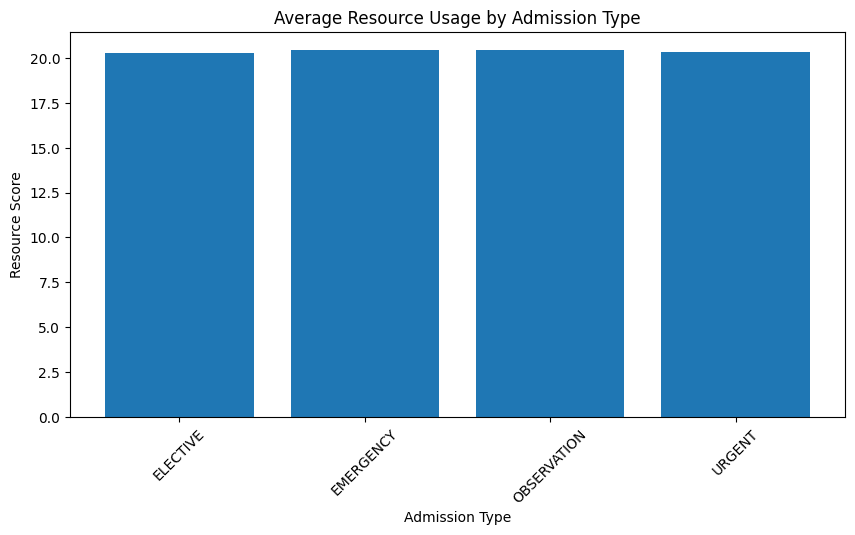

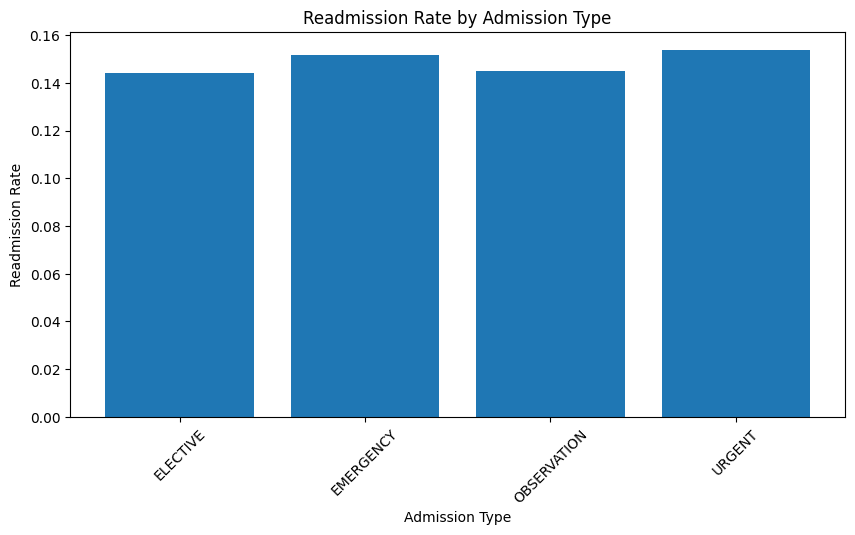

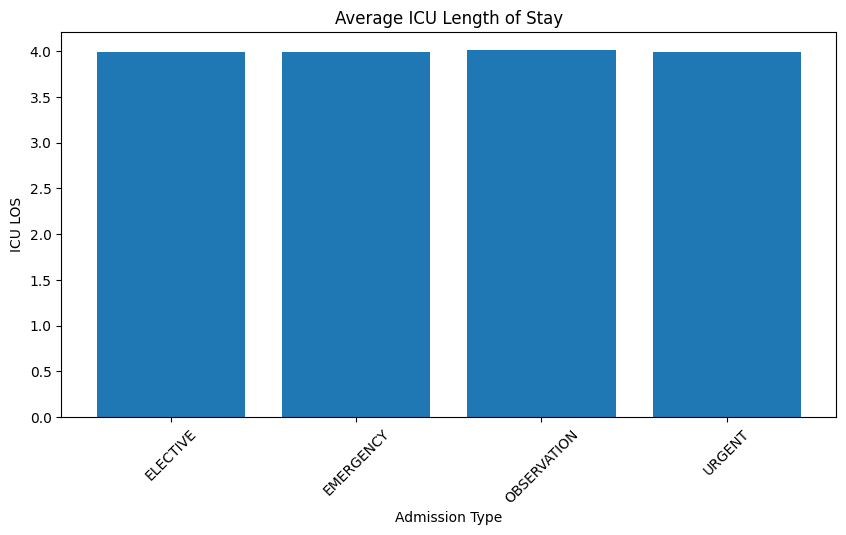

In [8]:
# plots
# =====================================================

# average los
plt.figure(figsize=(10,5))

plt.bar(
    admission_analysis["admission_type"],
    admission_analysis["Average_LOS"]
)

plt.title(
    "Average Length of Stay by Admission Type"
)

plt.xlabel(
    "Admission Type"
)

plt.ylabel(
    "Average LOS (Days)"
)

plt.xticks(rotation=45)

plt.show()


# resource utilization
plt.figure(figsize=(10,5))

plt.bar(
    admission_analysis["admission_type"],
    admission_analysis["Average_Resource"]
)

plt.title(
    "Average Resource Usage by Admission Type"
)

plt.xlabel(
    "Admission Type"
)

plt.ylabel(
    "Resource Score"
)

plt.xticks(rotation=45)

plt.show()


# readmission rate
plt.figure(figsize=(10,5))

plt.bar(
    admission_analysis["admission_type"],
    admission_analysis["Readmission_Rate"]
)

plt.title(
    "Readmission Rate by Admission Type"
)

plt.xlabel(
    "Admission Type"
)

plt.ylabel(
    "Readmission Rate"
)

plt.xticks(rotation=45)

plt.show()


# ICU utilization
plt.figure(figsize=(10,5))

plt.bar(
    admission_analysis["admission_type"],
    admission_analysis["Average_ICU_LOS"]
)

plt.title(
    "Average ICU Length of Stay"
)

plt.xlabel(
    "Admission Type"
)

plt.ylabel(
    "ICU LOS"
)

plt.xticks(rotation=45)

plt.show()

In [9]:
# resource hotspots
# =====================================================
high_resource = master.sort_values(
    by="resource_score",
    ascending=False
)

high_resource = high_resource.head(20)

print(
    high_resource[
        [
            "hadm_id",
            "resource_score",
            "los_days",
            "icu_los",
            "mortality"
        ]
    ]
)

       hadm_id  resource_score  los_days  icu_los  mortality
16691   216691              35        17     1.33          0
4460    204460              35        12     2.24          0
22943   222943              35         3     3.77          0
5595    205595              35        10     5.16          0
7189    207189              35        13     2.69          0
20000   220000              35        19     3.28          1
807     200807              35        12     1.34          0
22559   222559              35         8     1.45          0
14783   214783              35        14     4.21          0
14707   214707              35         2     4.82          0
21904   221904              35        12     2.02          0
13736   213736              34        17     4.14          0
21250   221250              34        11     8.73          0
10349   210349              34        10     3.88          0
13492   213492              34         2     2.65          0
1858    201858          

In [10]:
# longest stays
# =====================================================

long_stays = master.sort_values(
    by="los_days",
    ascending=False
)

long_stays = long_stays.head(20)

print(
    long_stays[
        [
            "hadm_id",
            "los_days",
            "resource_score",
            "icu_los"
        ]
    ]
)

       hadm_id  los_days  resource_score  icu_los
3971    203971        19              27     3.70
3970    203970        19              11     2.72
25054   225054        19              29     0.71
2645    202645        19              22     6.44
11044   211044        19              23     0.55
11034   211034        19              15     1.83
11019   211019        19              25     0.14
11114   211114        19              17     8.01
24820   224820        19              26     0.78
24817   224817        19              23     6.04
50      200050        19              17     9.40
24787   224787        19              24     1.39
24777   224777        19              30     2.18
40      200040        19              18     1.49
37      200037        19              26     4.11
34      200034        19              26     1.82
24924   224924        19              22     6.70
73      200073        19              21     3.54
24735   224735        19              19     9.43



Average Efficiency Score: 73.88
admission_type
EMERGENCY      74.088107
ELECTIVE       73.931364
URGENT         73.781465
OBSERVATION    73.735696
Name: efficiency_score, dtype: float64


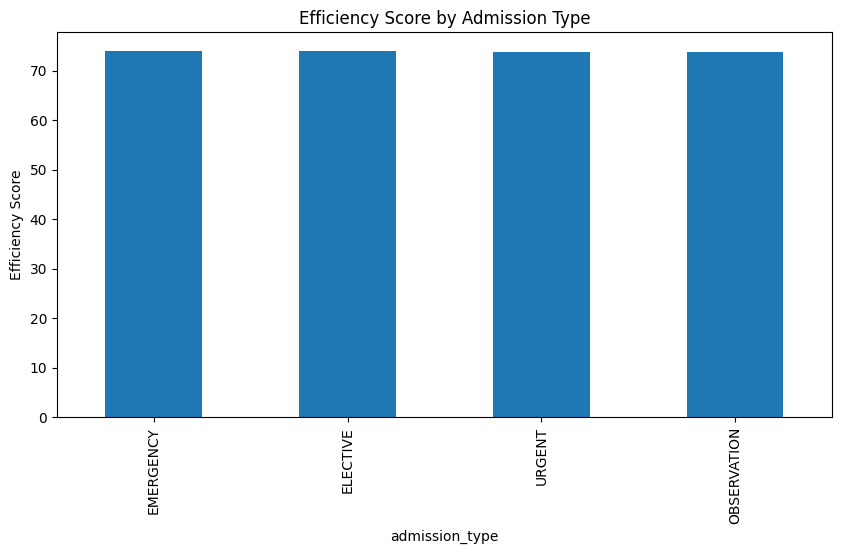

In [11]:
# efficiency
# =====================================================

# efficiency score
# lower LOS and lower resource use produce higher efficiency scores
master["efficiency_score"] = (

    100

    - (master["los_days"] * 2)

    - (master["resource_score"] * 0.3)

)

average_efficiency = master[
    "efficiency_score"
].mean()

print()
print("Average Efficiency Score: " + str(round(average_efficiency, 2)))


# efficiency by admission type
efficiency_by_type = master.groupby(
    "admission_type"
)["efficiency_score"].mean()

efficiency_by_type = efficiency_by_type.sort_values(
    ascending=False
)

print(efficiency_by_type)

# plot
plt.figure(figsize=(10,5))

efficiency_by_type.plot(
    kind="bar"
)

plt.title(
    "Efficiency Score by Admission Type"
)

plt.ylabel(
    "Efficiency Score"
)

plt.show()

In [12]:
# top bottlenecks
# =====================================================

bottlenecks = admission_analysis.sort_values(
    by=[
        "Average_LOS",
        "Average_Resource",
        "Readmission_Rate"
    ],
    ascending=False
)

print(bottlenecks.head())

  admission_type  Admissions  Average_LOS  Average_Resource  Average_ICU_LOS  \
2    OBSERVATION        6236    10.067832         20.428801         4.009267   
3         URGENT        6210    10.059581         20.331240         3.986424   
0       ELECTIVE        6332     9.993051         20.275111         3.985458   
1      EMERGENCY        6281     9.891896         20.427002         3.985814   

   Readmission_Rate  Mortality_Rate  
2          0.144965        0.101988  
3          0.153623        0.099839  
0          0.144188        0.097126  
1          0.151727        0.099666  


In [15]:
# exporting result
# =====================================================

admission_analysis.to_csv(
    f"{DATA_PATH}/operations_dashboard.csv",
    index=False
)

bottlenecks.to_csv(
    f"{DATA_PATH}/bottleneck_analysis.csv",
    index=False
)

kpi_table.to_csv(
    f"{DATA_PATH}/hospital_kpis.csv",
    index=False
)

print("Files saved successfully.")


# summary
print(
    """
Potential bottlenecks include:

1. Admission types with the longest stays

2. Admission types using the most resources

3. Admission types with the highest ICU utilization

4. Admission types with the highest readmission rates

5. Admission types with the lowest efficiency scores

Review the ranking tables above to identify
areas where hospital operations can be improved.
"""
)

Files saved successfully.

Potential bottlenecks include:

1. Admission types with the longest stays

2. Admission types using the most resources

3. Admission types with the highest ICU utilization

4. Admission types with the highest readmission rates

5. Admission types with the lowest efficiency scores

Review the ranking tables above to identify
areas where hospital operations can be improved.

